In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from keras import backend as K
from keras.models import Model, Sequential
from keras.layers import Dropout, Flatten, Dense, Activation, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras.utils import to_categorical

import os, cv2

from tqdm import tqdm

In [ ]:
PATH = '../input/horses-or-humans-dataset/horse-or-human/train'

X = []
Z = []

IMG_SIZE = 256

In [ ]:
for folder in os.listdir(PATH):
    path_folder = PATH + '/' + folder
    for img in tqdm(os.listdir(path_folder)):
        name = img
        label = folder
        path = os.path.join(path_folder,img)
        img = cv2.imread(path,cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))

        X.append(np.array(img))
        Z.append([str(label),name])

In [ ]:
le = LabelEncoder()
L = []
for i in range(len(Z)):
    L.append(Z[i][0])
Y = le.fit_transform(L)
Y = to_categorical(Y,2)
l = []
for i in range(len(Y)):
    l.append([Y[i], Z[i][1]])
Y = l
X = np.array(X)
X = X/IMG_SIZE

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [ ]:
# We build y_train and y_test (with just the labels)

train_list = []
for l in y_train:
    train_list.append(l[0])

test_list = []
for l in y_test:
    test_list.append(l[0])

y_train = train_list
y_test = test_list

In [ ]:
# We turn y_train and y_test into a single array, so we can use it in the model

for i in range(len(y_train)):
    y_train[i] = list(y_train[i])
y_train = np.asarray(y_train)

for i in range(len(y_test)):
    y_test[i] = list(y_test[i])
y_test = np.asarray(y_test)

y_test[:10]

In [ ]:
# Convolutional Network
model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',activation ='relu', input_shape = (256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dense(2, activation = "softmax"))

model.compile(optimizer=Adam(),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

In [ ]:
batch_size=50
epochs=5

history = model.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data = (x_test,y_test))

In [26]:
x_new = x_test
y_pred = model.predict_classes(x_new)
y_pred = list(map(lambda x: "horses" if (x==0) else "humans",y_pred))

y_pred[:10]

/opt/conda/lib/python3.7/site-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


['horses',
 'horses',
 'horses',
 'horses',
 'humans',
 'humans',
 'humans',
 'horses',
 'horses',
 'humans']

In [27]:
y_true = y_test.tolist()

for i in range(len(y_true)):
    y_true[i] = np.argmax(np.array(y_true[i]))

y_true = list(map(lambda x: "horses" if (x==0) else "humans",y_true))

print(y_true[:10])

['horses', 'horses', 'horses', 'horses', 'humans', 'humans', 'humans', 'horses', 'horses', 'humans']


In [28]:
cm = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=["horses","humans"])
print(cm)

[[101   0]
 [  0 105]]


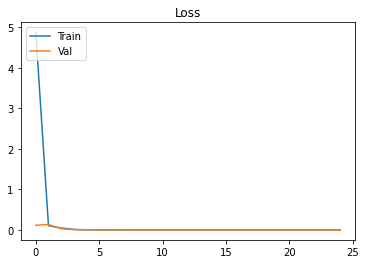

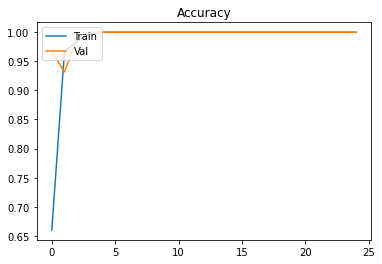

In [32]:
loss_curve = history.history["loss"]
acc_curve = history.history["accuracy"]

acc_val_curve = history.history["val_accuracy"]
loss_val_curve = history.history["val_loss"]

plt.plot(loss_curve, label="Train")
plt.plot(loss_val_curve, label="Val")
plt.legend(loc='upper left')
plt.title("Loss")
plt.show()

plt.plot(acc_curve, label="Train")
plt.plot(acc_val_curve, label="Val")
plt.legend(loc='upper left')
plt.title("Accuracy")
plt.show()